In [1]:
import pandas as pd
import numpy as np
import polars as pl
import json
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Import User Details

In [2]:
user_details = pl.read_json("user.json", infer_schema_length=100000)

# Import Matches and Chats

In [3]:
def convert_match_timestamps(match):
    # Convert chat timestamps
    if "chats" in match:
        for chat in match["chats"]:
            if "timestamp" in chat:
                if "." in chat["timestamp"]:
                    chat["timestamp"] = datetime.strptime(chat["timestamp"], "%Y-%m-%d %H:%M:%S.%9f")
                else:
                    chat["timestamp"] = datetime.strptime(chat["timestamp"], "%Y-%m-%d %H:%M:%S")
    
    # Convert match timestamps
    if "match" in match:
        for m in match["match"]:
            if "timestamp" in m:
                if "." in m["timestamp"]:
                    m["timestamp"] = datetime.strptime(m["timestamp"], "%Y-%m-%d %H:%M:%S.%9f")
                else:
                    m["timestamp"] = datetime.strptime(m["timestamp"], "%Y-%m-%d %H:%M:%S")
    
    # Convert like timestamps
    if "like" in match:
        for like in match["like"]:
            if "timestamp" in like:
                if "." in like["timestamp"]:
                    like["timestamp"] = datetime.strptime(like["timestamp"], "%Y-%m-%d %H:%M:%S.%9f")
                else:
                    like["timestamp"] = datetime.strptime(like["timestamp"], "%Y-%m-%d %H:%M:%S")
            # Handle nested like timestamps
            if "like" in like:
                for nested_like in like["like"]:
                    if "timestamp" in nested_like:
                        if "." in nested_like["timestamp"]:
                            nested_like["timestamp"] = datetime.strptime(nested_like["timestamp"], "%Y-%m-%d %H:%M:%S.%9f")
                        else:
                            nested_like["timestamp"] = datetime.strptime(nested_like["timestamp"], "%Y-%m-%d %H:%M:%S")

In [4]:
# Read matches JSON and convert timestamps
with open("matches.json", "r") as f:
    matches_data = json.load(f)

# Convert all timestamp strings to datetime objects
for match in matches_data:
    try:
        convert_match_timestamps(match)
    except Exception as e:
        print(f"Error converting timestamps: {e}, {match}")

Add date column

In [5]:
matches = pl.DataFrame(matches_data)
matches = matches.with_columns(
    pl.lit(None).cast(pl.Datetime).alias("date")
)
date_col = []
for match in matches.iter_rows(named=True):
    if match["match"] is not None:
        date_col.append(match["match"][0]["timestamp"])
    elif match["block"] is not None:
        # Extract timestamp from block dictionary
        block_timestamp = match["block"][0]["timestamp"]
        # Parse different timestamp formats
        try:
            if "." in block_timestamp:
                # Format with microseconds: "2025-09-29 21:36:00.539958"
                date_col.append(datetime.strptime(block_timestamp, "%Y-%m-%d %H:%M:%S.%f"))
            else:
                # Format without microseconds: "2025-08-21 19:15:01"
                date_col.append(datetime.strptime(block_timestamp, "%Y-%m-%d %H:%M:%S"))
        except ValueError as e:
            # If parsing fails, append None
            print(f"Error parsing block timestamp: {block_timestamp}, error: {e}")
            date_col.append(None)
    else:
        date_col.append(None)

matches = matches.with_columns(
    pl.Series(name="date", values=date_col)
)


### Number of Matches

In [6]:
from polars import first


first_match_date = datetime.strftime(matches["date"][0], "%Y-%m-%d")
last_match_date = datetime.strftime(matches["date"][-1], "%Y-%m-%d")
num_matches = len(matches)
print(f"In total, I had {num_matches} matches between {first_match_date} and {last_match_date}")

In total, I had 1598 matches between 2025-07-08 and 2025-12-15


## Avg Time Elapsed Between Match and First Message Sent

In [7]:
from datetime import timedelta

def format_timedelta(td):
    """Format a timedelta object into a readable string"""
    total_seconds = int(td.total_seconds())
    days = total_seconds // 86400
    hours = (total_seconds % 86400) // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    parts = []
    if days > 0:
        parts.append(f"{days} day{'s' if days != 1 else ''}")
    if hours > 0:
        parts.append(f"{hours} hour{'s' if hours != 1 else ''}")
    if minutes > 0:
        parts.append(f"{minutes} min{'s' if minutes != 1 else ''}")
    if seconds > 0 or len(parts) == 0:
        parts.append(f"{seconds} second{'s' if seconds != 1 else ''}")
    
    return ", ".join(parts)

total_time_elapsed = timedelta()
count = 0

for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        match_timestamp = match["match"][0]["timestamp"]
        first_message_time = match["chats"][0]["timestamp"]
        
        # Only calculate if both timestamps exist
        if match_timestamp and first_message_time:
            time_elapsed = first_message_time - match_timestamp 
            total_time_elapsed += time_elapsed
            count += 1

if count > 0:
    avg_time_elapsed = total_time_elapsed / count
    print(f"Average time elapsed between match and first message sent: {format_timedelta(avg_time_elapsed)}")
else:
    print("No valid matches with both match and chat timestamps")


Average time elapsed between match and first message sent: 1 day, 21 mins, 37 seconds


## Avg Response Rate

In [8]:
response_rate = []
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        match_timestamp = match["date"]
        first_message_time = match["chats"][0]["timestamp"]
        
        # Only calculate if both timestamps exist
        if match_timestamp and first_message_time:
            time_elapsed = first_message_time - match_timestamp
            response_rate.append(time_elapsed.total_seconds() / 60.0)

avg_response_rate = sum(response_rate) / len(response_rate)
print(f"Average response rate: {avg_response_rate} minutes")

## Step 3. Avg Number of Messages Sent


num_messages = []
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        num_messages.append(len(match["chats"]))

avg_num_messages = sum(num_messages) / len(num_messages)
print(f"Average number of messages sent: {avg_num_messages}")

Average response rate: 1461.6177014861996 minutes
Average number of messages sent: 10.751592356687897


# Average Conversation Length

In [9]:
conversation_length = []
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        conversation_length.append(len(match["chats"]))

avg_conversation_length = sum(conversation_length) / len(conversation_length)
print(f"Average conversation length: {avg_conversation_length} messages")


Average conversation length: 10.751592356687897 messages


# How many times did I give my phone number in chat?

In [10]:
phone_number_count = 0
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        for chat in match["chats"]:
            if chat:
                if "body" in chat:
                    if chat["body"] and "551" in chat["body"]:
                        phone_number_count += 1
print(f"I gave my phone number {phone_number_count} times")

I gave my phone number 46 times


# Match to Conversion: How Many Never Messaged?

In [11]:
never_messaged = 0
for match in matches.iter_rows(named=True):
    if match["match"] and not match["chats"]:
        never_messaged += 1
print(f"I never messaged {never_messaged} matches")


I never messaged 25 matches


# Ghosting Analysis: How Many Chats Only Had 1-2 Messages?

In [12]:
num_one_to_two_messages = 0
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        if len(match["chats"]) >= 1 and len(match["chats"]) <= 2:
            num_one_to_two_messages += 1
print(f"I had {num_one_to_two_messages} chats with only 1-2 messages")

I had 43 chats with only 1-2 messages


# Visualizations

# Number of Matches per Week

Weekly Match Counts:
         week  count
0  2025-07-07      9
1  2025-07-14     14
2  2025-07-21      4
3  2025-07-28      6
4  2025-08-11      7
5  2025-08-18      9
6  2025-08-25     10
7  2025-09-01     13
8  2025-09-08     10
9  2025-09-15     25
10 2025-09-22     22
11 2025-09-29      8
12 2025-10-06      2
13 2025-10-13     11
14 2025-10-20     10
15 2025-10-27      5
16 2025-11-03      8
17 2025-11-10      5
18 2025-11-24      3
19 2025-12-01      1

Total matches: 182
Average matches per week: 9.1
Max matches in a week: 25
Min matches in a week: 1


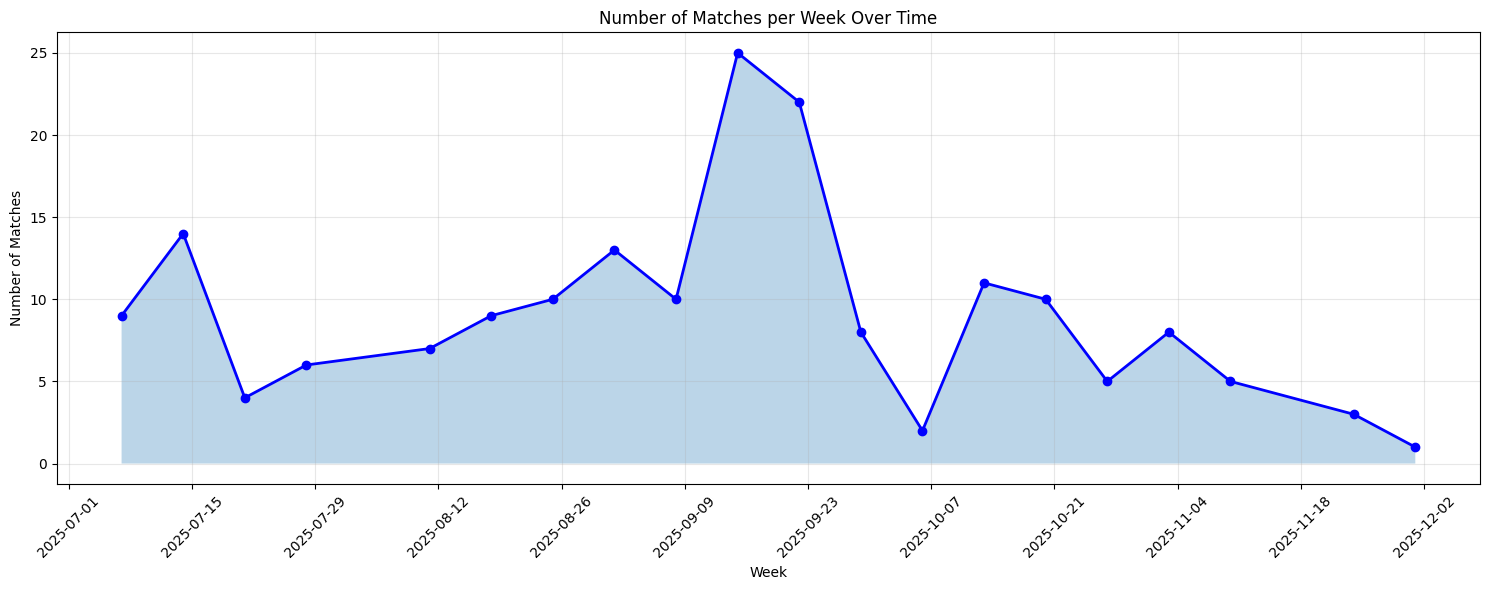

In [13]:
# Get all match dates (excluding blocked profiles)
match_dates = []
for match in matches.iter_rows(named=True):
    if match["match"] is not None and match["date"] is not None:
        match_dates.append(match["date"])

# Create a DataFrame with match dates
matches_timeline = pl.DataFrame({"match_date": match_dates})

# Convert to pandas for easier date grouping
matches_pd = matches_timeline.to_pandas()
matches_pd['match_date'] = pd.to_datetime(matches_pd['match_date'])

# Group by week and count matches
matches_pd['week'] = matches_pd['match_date'].dt.to_period('W').dt.start_time
weekly_matches = matches_pd.groupby('week').size().reset_index(name='count')

# Display the weekly counts
print("Weekly Match Counts:")
print(weekly_matches.to_string())
print(f"\nTotal matches: {len(match_dates)}")
print(f"Average matches per week: {weekly_matches['count'].mean():.1f}")
print(f"Max matches in a week: {weekly_matches['count'].max()}")
print(f"Min matches in a week: {weekly_matches['count'].min()}")

# Plot weekly matches
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(weekly_matches['week'], weekly_matches['count'], marker='o', linestyle='-', linewidth=2, color='blue')
ax.fill_between(weekly_matches['week'], weekly_matches['count'], alpha=0.3)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel("Week")
plt.ylabel("Number of Matches")
plt.title("Number of Matches per Week Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Number of Messages Per Week

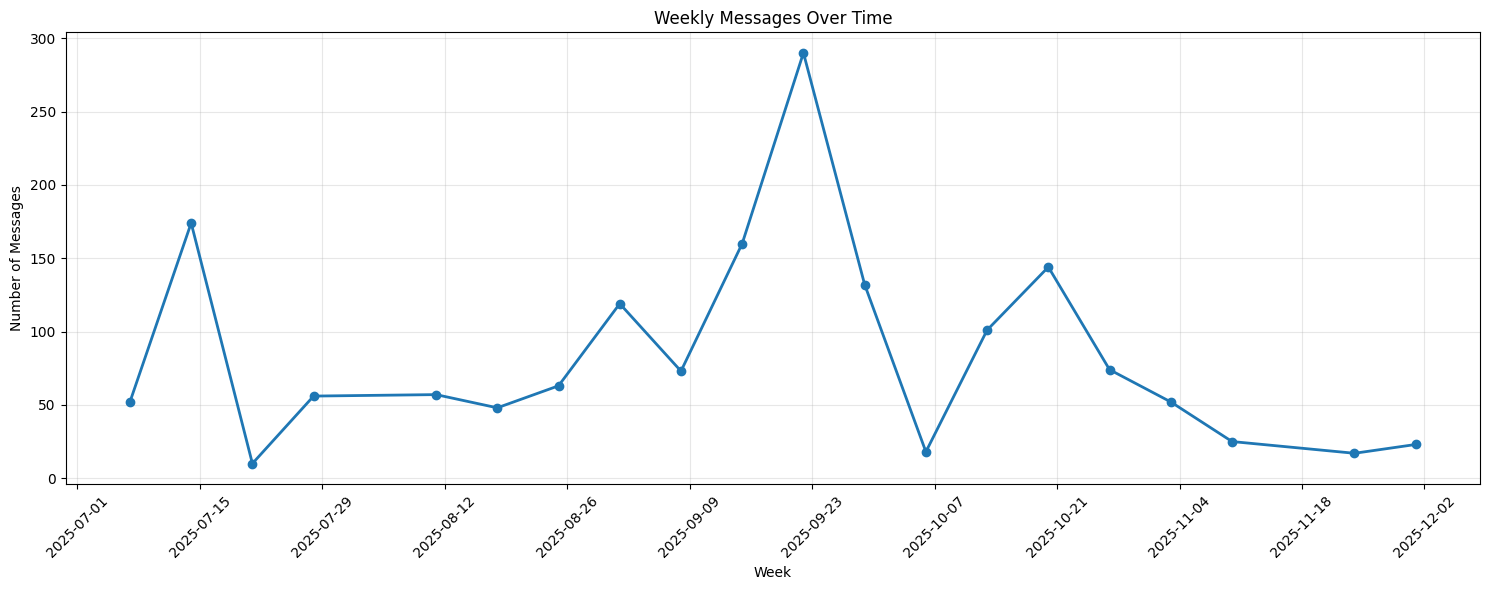

Total messages: 1688
Average messages per week: 84.4


In [14]:
# Plot number of messages over time on weekly basis
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Collect all chat messages with timestamps
all_messages = []
for match in matches.iter_rows(named=True):
    if match["chats"]:
        for chat in match["chats"]:
            if chat and "timestamp" in chat:
                all_messages.append(chat["timestamp"])

# Create a DataFrame with all message timestamps
messages_df = pl.DataFrame({"timestamp": all_messages})

# Convert to pandas for easier date manipulation
import pandas as pd
messages_pd = messages_df.to_pandas()

# Group by week and count messages
messages_pd['week'] = pd.to_datetime(messages_pd['timestamp']).dt.to_period('W').dt.start_time
weekly_counts = messages_pd.groupby('week').size().reset_index(name='count')

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(weekly_counts['week'], weekly_counts['count'], marker='o', linestyle='-', linewidth=2)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel("Week")
plt.ylabel("Number of Messages")
plt.title("Weekly Messages Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total messages: {len(all_messages)}")
print(f"Average messages per week: {weekly_counts['count'].mean():.1f}")

## Conversation Length Histogram

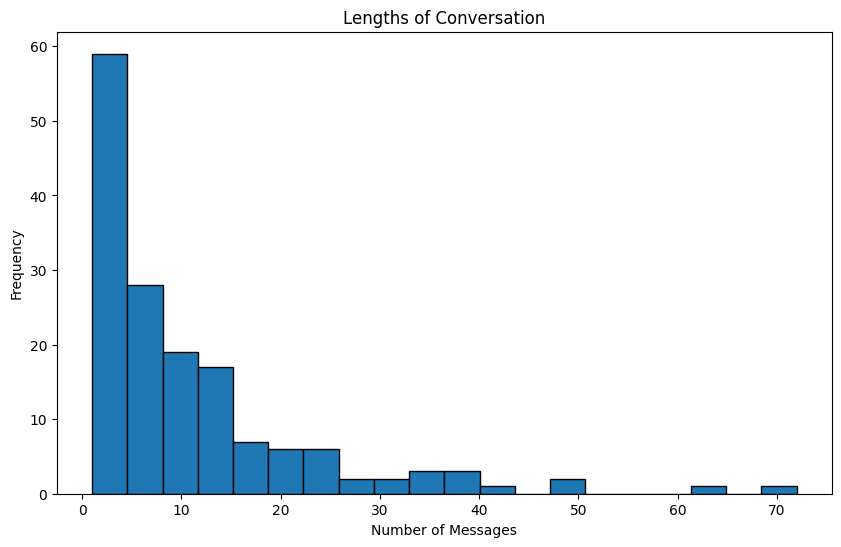

In [15]:
lengths_of_conversation = []
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        lengths_of_conversation.append(len(match["chats"]))

plt.figure(figsize=(10, 6))
plt.title("Lengths of Conversation")
plt.xlabel("Number of Messages")
plt.ylabel("Frequency")
plt.hist(lengths_of_conversation, bins=20, edgecolor='black')
plt.show()


## Response Time Heatmap: When do Conversations Happen?

In [16]:
# create heatmap of average response time from match to first message using hvplot.polars
import hvplot.polars

# Build response_time list
response_times = []
for match in matches.iter_rows(named=True):
    if match["match"] and match["chats"]:
        time_diff = match["chats"][0]["timestamp"] - match["date"]
        if time_diff.total_seconds() > 0:
            response_times.append(time_diff.total_seconds() / 3600)  # Convert to hours
        else:
            response_times.append(0.0)
    else:
        response_times.append(0.0)

# Add response_time column to matches
matches = matches.with_columns(
    pl.Series(name="response_time", values=response_times)
)

/var/folders/qc/t6lsmmpx4_lgfsf3ry51ftbm0000gn/T/ipykernel_81800/1531493284.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = matches_pd.groupby(['week', 'response_time_bin']).size().reset_index(name='count')


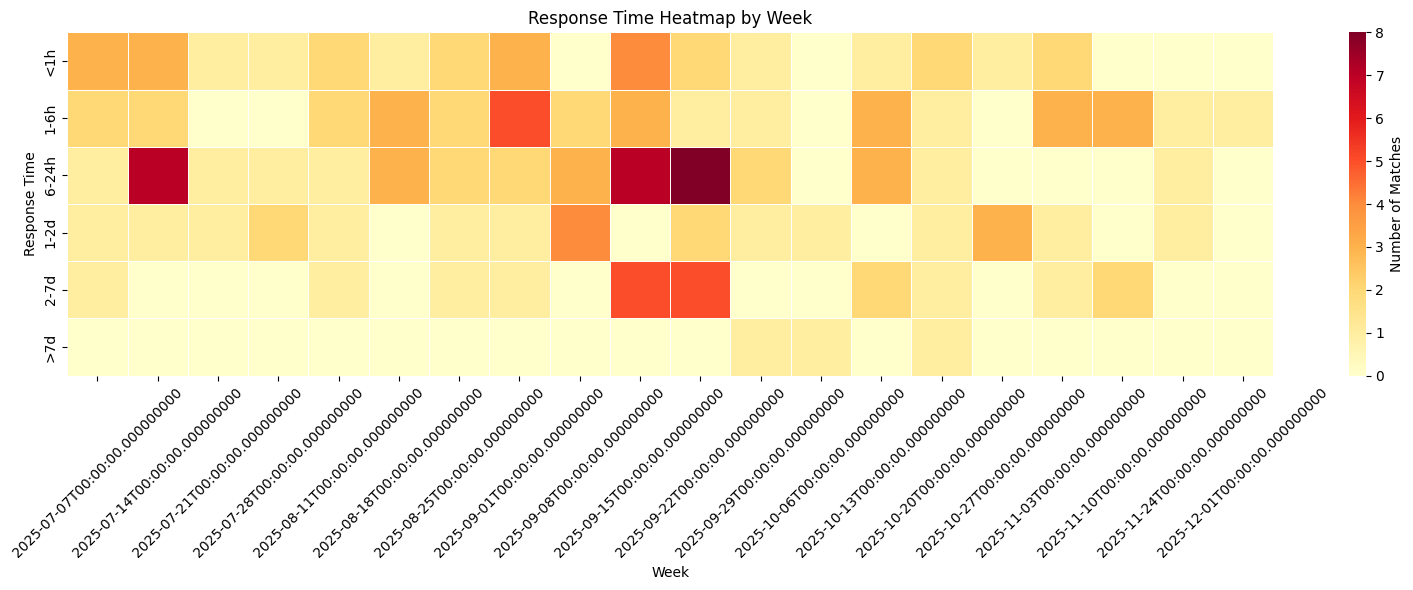

Matches with responses: 152


In [17]:
# Filter to only matches with response times
matches_with_responses = matches.filter(pl.col("response_time") > 0)

# Create bins for better heatmap visualization
matches_pd = matches_with_responses.to_pandas()
matches_pd['date'] = pd.to_datetime(matches_pd['date'])
matches_pd['week'] = matches_pd['date'].dt.to_period('W').dt.start_time
matches_pd['response_time_bin'] = pd.cut(matches_pd['response_time'], 
                                         bins=[0, 1, 6, 24, 48, 168, float('inf')],
                                         labels=['<1h', '1-6h', '6-24h', '1-2d', '2-7d', '>7d'])

# Create pivot table for heatmap
heatmap_data = matches_pd.groupby(['week', 'response_time_bin']).size().reset_index(name='count')
pivot_data = heatmap_data.pivot(index='response_time_bin', columns='week', values='count').fillna(0)

# Plot using matplotlib for better control
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_data, cmap='YlOrRd', cbar_kws={'label': 'Number of Matches'}, 
            fmt='g', linewidths=0.5, ax=ax)
plt.title('Response Time Heatmap by Week')
plt.xlabel('Week')
plt.ylabel('Response Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Matches with responses: {len(matches_with_responses)}")